In [ ]:
from pythtb import TBModel, Lattice, Wannier, Mesh, WFArray
from pythtb.utils import levi_civita, finite_diff_coeffs
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import polar

1D Tight-binding Model

In [37]:
def spd_chain(t, delta_E, E0=0):
    lat = [[1]]
    orbs = [[0], [0], [0]]
    lat = Lattice(lat, orbs, periodic_dirs=...)

    model = TBModel(lat)
    model.set_onsite(E0, 0)
    model.set_onsite(-E0+delta_E/2, 1)
    model.set_onsite(-E0-delta_E/2, 2)

    tss = -t
    tpp = -t
    tsp = 0.6 * t
    tdd = -0.5 * t
    tsd = 0.5 * t
    tpd = 0.3 * t

    model.set_hop(tss, 0, 0, [1])
    model.set_hop(tpp, 1, 1, [1])
    model.set_hop(tsp, 0, 1, [1])
    model.set_hop(-tsp, 1, 0, [1])
    model.set_hop(tdd, 2, 2, [1])
    model.set_hop(tpd, 2, 1, [1])
    model.set_hop(-tpd, 1, 2, [1])
    model.set_hop(tsd, 0, 2, [1])
    model.set_hop(-tsd, 2, 0, [1])

    return model


def fd(U_k, dk_mu, order_eps, mode='central'):
    coeffs, stencil = finite_diff_coeffs(order=order_eps, mode=mode)

    fd_sum = np.zeros_like(U_k)

    for s, c in zip(stencil, coeffs):
        fd_sum += c * np.roll(U_k, shift=-s, axis=0)

    v = fd_sum / (dk_mu)
    return v

In [5]:
delta_E = 4
t_triv = 0.35
t_top = 1.3

sp_model_triv = spd_chain(t_triv, delta_E)
sp_model_top = spd_chain(t_top, delta_E)

(<Figure size 640x480 with 1 Axes>, <Axes: ylabel='Energy $E(\\mathbf{{k}})$'>)

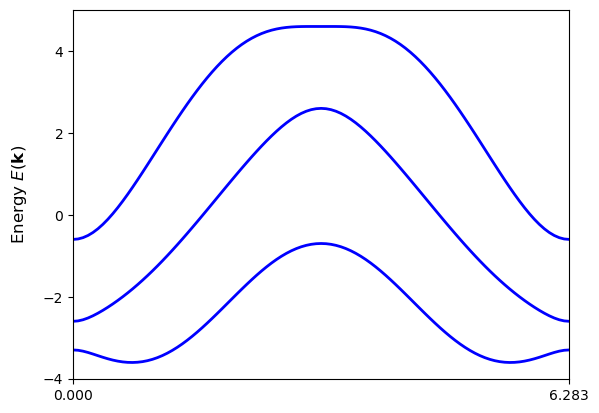

In [14]:
sp_model_top.plot_bands([0, 1])

In [9]:
mesh = Mesh(['k'])
mesh.build_grid([1000])
bloch_wfs_sp = WFArray(sp_model_top.lattice, mesh)
bloch_wfs_sp.solve_model(sp_model_top)

In [10]:
u_nk_sp = bloch_wfs_sp.u_nk
psi_nk_sp = bloch_wfs_sp.psi_nk

In [ ]:
print(bloch_wfs_sp.berry_phase(axis_idx = 0, state_idx=[0]))
print(bloch_wfs_sp.berry_phase(axis_idx = 0, state_idx=[1]))
print(bloch_wfs_sp.berry_phase(axis_idx = 0, state_idx=[2]))

-0.050723073353369764
0.024358449650466928
0.026358873165929143


# Testing note derivations with spd model

In [19]:
def chain(t, delta, lmbd):
    lat = [[1]]
    orb = [[0],[1/3],[2/3]]
    lattice = Lattice(lat, orb, periodic_dirs=[0])
    model = TBModel(lattice)
    
    model.set_hop(t, 0, 1, [0])
    model.set_hop(t, 1, 2, [0])
    model.set_hop(t, 2, 0, [1])
    onsite_0 = -delta*np.cos(2.0*np.pi*(lmbd-0.0/3.0))
    onsite_1 = -delta*np.cos(2.0*np.pi*(lmbd-1.0/3.0))
    onsite_2 = -delta*np.cos(2.0*np.pi*(lmbd-1.5/3.0))
    model.set_onsite([onsite_0, onsite_1, onsite_2])

    return model

(<Figure size 640x480 with 2 Axes>, <Axes: ylabel='Energy $E(\\mathbf{{k}})$'>)

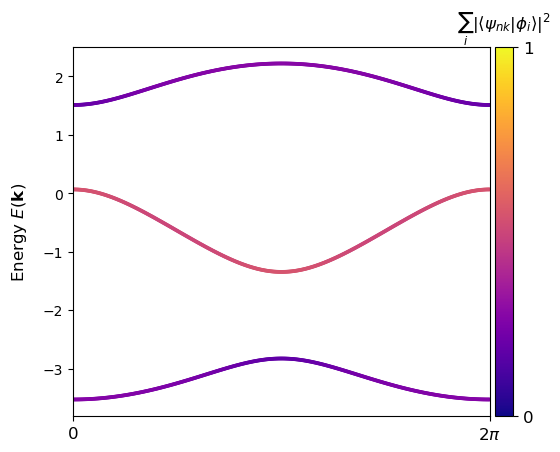

In [21]:
# delta_E = 5
# t = 2
# spd_model = spd_chain(t, delta_E)

t = -1.3
delta = 2.0
lmbd = 0.3
model = chain(t, delta, lmbd)

orb_vecs = model.get_orb_vecs()

k_path = [0, 1]
k_label = [0, r"$2\pi$"]
model.plot_bands(k_nodes=k_path, k_node_labels=k_label, nk=500, cmap='plasma', proj_orb_idx=[2])

In [24]:
nk = 50000
dk = 1/nk
dk_cart = 2*np.pi / nk
kpts = np.linspace(0, 1, nk, endpoint=False)[:, None]
print(1/nk, kpts[1]-kpts[0])

# Velocity matrix
v_mu = model.velocity(kpts)[0]

mesh = Mesh(['k'])
mesh.build_grid([nk])

# Bloch class
bloch_wfs = WFArray(model.lattice, mesh)
bloch_wfs.solve_model(model)
u_nk_sp = bloch_wfs.u_nk
psi_nk_sp = bloch_wfs.psi_nk
energies = bloch_wfs.energies

bphase = bloch_wfs.berry_phase(axis_idx=0, state_idx=[0])

print(bphase)
print(np.allclose(psi_nk_sp, u_nk_sp)) # All orbitals at origin of home cell (no phase in psi)

2e-05 [2.e-05]
2.414369757286346
False


In [26]:
# Occupied (lower two) and conduction (last) bands
u_occ, psi_occ = u_nk_sp[:, :2, :], psi_nk_sp[:, :2, :]
u_con, psi_con = u_nk_sp[:, -1, :][:, None, :], psi_nk_sp[:, -1, :][:, None, :]

E_occ, E_con = energies[:, :2], energies[:, -1][:, None]

# Bloch class for occupied bands
bloch_occ = WFArray(model.lattice, mesh)
bloch_occ.solve_model(model)
bloch_occ.remove_states([2])
# bloch_occ.set_wfs(psi_occ, cell_periodic=True)

# Bloch class for conduction bands
bloch_con = WFArray(model.lattice, mesh)
bloch_con.solve_model(model)
bloch_con.remove_states([0, 1])

$S_{nm}(k) = \langle \psi_{nk} | g_{m} \rangle $, $\rightarrow S = V \Sigma W^{\dagger}$, $\rightarrow U(k) = V W^{\dagger}$

In [27]:
def get_trial_wfs(tf_list, norb, nspin=1):
    # number of trial functions to define
    num_tf = len(tf_list)
    if nspin == 2:
        tfs = np.zeros([num_tf, norb, 2], dtype=complex)
        for j, tf in enumerate(tf_list):
            assert isinstance(tf, (list, np.ndarray)), "Trial function must be a list of tuples"
            for orb, spin, amp in tf:
                tfs[j, orb, spin] = amp
            tfs[j] /= np.linalg.norm(tfs[j])
    elif nspin == 1:
        # initialize array containing tfs = "trial functions"
        tfs = np.zeros([num_tf, norb], dtype=complex)
        for j, tf in enumerate(tf_list):
            assert isinstance(tf, (list, np.ndarray)), "Trial function must be a list of tuples"
            for site, amp in tf:
                tfs[j, site] = amp
            tfs[j] /= np.linalg.norm(tfs[j])
    return tfs 

In [33]:
# For tilde (projection) gauge states
bloch_tilde = WFArray(model.lattice, mesh, nstates=2)

# Trial wavefunctions as delta on first and second orbital
tf_list = [[(0,0), (1,1), (2,0)], [(0,0), (1,0), (2,1)]]
twfs = get_trial_wfs(tf_list, model.norb, nspin=1)

# Overlap function S_nm = <psi_nk| g_m> with occupied bands
S_occ = np.einsum("...nj, mj -> ...nm", psi_occ.conj(), twfs)
S_con = np.einsum("...nj, mj -> ...nm", psi_con.conj(), twfs)

# SVD
W, Sig, Vh = np.linalg.svd(S_occ, full_matrices=True)
Sig_mat = np.einsum("...i, ij -> ...ij", Sig, np.eye(Sig.shape[-1]))
# Polar
pol =  np.array([polar(S_occ[k]) for k in range(S_occ.shape[0]) ])
U_p = pol[:, 0]
P = pol[:, 1]

# Unitary part
U_rot = W @ Vh

np.allclose(U_p, U_rot)

True

(0.0, 1.01)

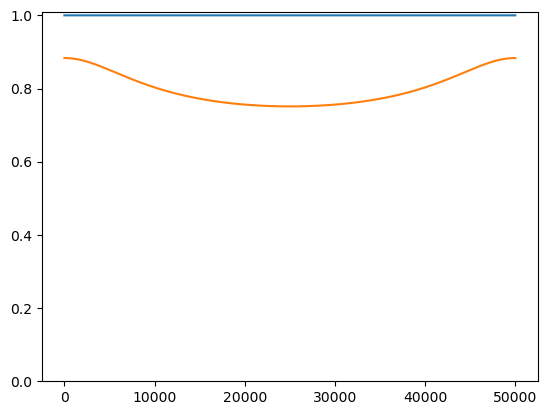

In [30]:
# Singular values
plt.plot(Sig)
plt.ylim(0,1+0.01)

$|\tilde{\psi}_{nk} \rangle = \sum_{m} U_{mn} |\psi_{mk}\rangle$

In [34]:
psi_tilde = np.einsum("...mn, ...mj -> ...nj", U_rot, psi_occ) # shape: (*nks, states, orbs*n_spin])

bloch_tilde.set_states(psi_tilde, is_cell_periodic=False)
u_tilde = bloch_tilde.u_nk

$|\partial_{\mu} u_{nk} \rangle$ from first order adiabatic

In [35]:
parmu_u_occ = np.zeros_like(u_occ, dtype=complex)
n_occ, n_con = u_occ.shape[-2], u_con.shape[-2]
for n in range(n_occ):
    for m in range(n_con):
        u_n_occ, u_m_con = u_occ[:, n, :], u_con[:, m, :]
        v_mu_mn = np.einsum("...j, ...jk, ...k", u_m_con.conj(), v_mu, u_n_occ)
        parmu_u_occ[:, n, :] += ( v_mu_mn / (E_occ[:, n] - E_con[:, m]) )[:, None] * u_m_con

Getting $|\partial_{\mu} \tilde{u}_{nk} \rangle$ from finite differences

In [38]:
deriv_u_tilde = fd(u_tilde, 1, order_eps=1, mode='forward')
A_tilde_fd = 1j * np.einsum("...ni, ...mj -> ...nm", u_tilde.conj(), deriv_u_tilde)

$\tilde{A}_{\mu}(k) = - \text{Im} \log U_{\mu}(k)$ where $U_{\mu}(k)$ is found from $M_{nm}^{\mu}(k) = \langle \tilde{u}_{n k} | \tilde{u}_{m k +\delta \mu} \rangle$ and $M = V \Sigma W^{\dagger}$ and $U_{\mu}(k) = VW^{\dagger}$

In [39]:
U_links_tilde = bloch_tilde.links()
U_links_en = bloch_occ.links()

# berry_conn_tilde = 1j * np.log(U_links_tilde)

eigvals, eigvecs = np.linalg.eig(U_links_tilde)
angles = -np.angle(eigvals)
angles_diag = np.einsum("...i, ij -> ...ij", angles, np.eye(angles.shape[-1]))
eigvecs_inv = np.linalg.inv(eigvecs)
berry_conn_tilde = np.matmul(np.matmul(eigvecs, angles_diag), eigvecs_inv) / dk

# berry_conn_en = 1j * np.log(U_links_en)

eigvals, eigvecs = np.linalg.eig(U_links_en)
angles = -np.angle(eigvals)
angles_diag = np.einsum("...i, ij -> ...ij", angles, np.eye(angles.shape[-1]))
eigvecs_inv = np.linalg.inv(eigvecs)
berry_conn_en = np.matmul(np.matmul(eigvecs, angles_diag), eigvecs_inv) / dk

print("A_mu Hermitian?", np.allclose(berry_conn_en[0], berry_conn_en[0].conj().swapaxes(-1,-2)))
print("tilde{A}_mu Hermitian?", np.allclose(berry_conn_en[0], berry_conn_en[0].conj().swapaxes(-1,-2)))

A_mu Hermitian? True
tilde{A}_mu Hermitian? True


$\phi_{\rm tot}$ unique mod $2\pi n$

In [40]:
phi_tot_til = np.sum(np.trace(berry_conn_tilde[0], axis1=-1, axis2=-2)) * dk
phi_tot_en = np.sum(np.trace(berry_conn_en[0], axis1=-1, axis2=-2)) * dk

diff = (phi_tot_en - phi_tot_til).real

print(phi_tot_en, phi_tot_til)
print(np.mod(abs(diff), 2*np.pi)-1*np.pi)
print("Unique phi mod 2pi?", np.allclose(np.mod(abs(diff), 2*np.pi), 0 ))

(6.6444402517081915-1.62172713439297e-19j) (6.644440251708232+1.8794707486654583e-22j)
-3.1415926535897523
Unique phi mod 2pi? True


$U^{\dagger} \partial_{\mu} U$ is anti-Hermitian. Testing this using $U^{\dagger} \partial_{\mu} U = P^{-1} ( S^{\dagger} \partial_{\mu} S  - P \partial_{\mu} P) P^{-1}$

In [42]:
evecs_conj_tf = u_nk_sp.conj()
evecs_T_tf = u_nk_sp.swapaxes(-1,-2)  # (n_kpts, n_beta, n_state, n_state)

v_k_rot = np.matmul(
        evecs_conj_tf[None, :, :, :],  # (1, n_kpts, n_state, n_state)
        np.matmul(
            v_mu,                       # (dim_k, n_kpts, n_state, n_state)
            evecs_T_tf[None, :, :, :]  # (1, n_kpts, n_beta, n_state, n_state)
        )
    )  

occ_idxs = np.arange(2)
cond_idxs = np.setdiff1d(np.arange(u_nk_sp.shape[-2]), occ_idxs)  # Identify conduction bands

# Compute energy denominators
delta_E = energies[..., None, :] - energies[..., :, None]
delta_E_occ_cond = np.take(np.take(delta_E, occ_idxs, axis=-2), cond_idxs, axis=-1)
delta_E_cond_occ = np.take(np.take(delta_E, cond_idxs, axis=-2), occ_idxs, axis=-1)
inv_delta_E_occ_cond_tf = 1 / delta_E_occ_cond
inv_delta_E_cond_occ_tf = 1 / delta_E_cond_occ

v_occ_cond = np.take(np.take(v_k_rot, occ_idxs, axis=-2), cond_idxs, axis=-1)
v_cond_occ = np.take(np.take(v_k_rot, cond_idxs, axis=-2), occ_idxs, axis=-1)
v_occ_cond = v_occ_cond * -inv_delta_E_occ_cond_tf
v_cond_occ = v_cond_occ * -inv_delta_E_occ_cond_tf

vhat = v_occ_cond[0] 

parmu_occ = np.sum(v_cond_occ[0], axis=-2)[:, :, None] * u_con #
parmu_S2 = v_occ_cond[0] @ S_con 
parmu_S2 += 1j* berry_conn_en[0] @ S_occ

orb_vecs = model.get_orb_vecs(cartesian=False)
r_twf = 2*np.pi * (orb_vecs.T[:, None, :] * twfs)
rhat = np.einsum("...nj, mj -> ...nm", psi_occ.conj(), r_twf[0])
parmu_S2 += -1j * rhat

print(v_occ_cond.shape)
print(delta_E.shape)
print(S_con.shape)

(1, 50000, 2, 1)
(50000, 3, 3)
(50000, 1, 2)


In [43]:
twfs.shape

(2, 3)

In [44]:
parmu_S = np.zeros_like(S_occ, dtype=complex)
v_mu_occ_con = np.einsum("...mj, ...jk, ...nk", u_occ.conj(), v_mu, u_con)
for n in range(S_occ.shape[-1]):
    for m in range(n_occ):
        for c in range(n_con):
            v_mu_mc = v_mu_occ_con[:, m, c]
            parmu_S[:, m, n] += ( v_mu_mc / (E_occ[:, m] - E_con[:, c]) ) * S_con[:, c, n]

# NOTE: This term was missing previously
parmu_S += 1j* berry_conn_en[0] @ S_occ
parmu_S += -1j * rhat

In [45]:
parmu_S[0]

array([[-0.20915643-1.33603116e+00j,  0.24378677-1.93214651e+00j],
       [-0.25093223-9.91497282e+04j, -0.17117913+1.15562561e+05j]])

In [46]:
parmu_S2[0]

array([[-0.20915643-1.33603116e+00j,  0.24378677-1.93214651e+00j],
       [-0.25093223-9.91497282e+04j, -0.17117913+1.15562561e+05j]])

In [47]:
S_check = W.conj().swapaxes(-1,-2) @ parmu_S @ Vh.conj().swapaxes(-1,-2)

numerator = Sig[..., :, None] * S_check + Sig[..., None, :] * S_check.conj().swapaxes(-1,-2)
denominator = Sig[..., :, None] + Sig[..., None, :]
    
# Elementwise division
P_check = (numerator / denominator)
parmuP = Vh.conj().swapaxes(-1,-2) @ P_check @ Vh
PparmuP = P @ parmuP

# PparmuP = Vh @ (parmu_S.conj().swapaxes(-1,-2) @ S_occ + S_occ.conj().swapaxes(-1,-2) @ parmu_S) @ Vh.conj().swapaxes(-1,-2)
# for a in range(PparmuP.shape[-2]):
#     for b in range(PparmuP.shape[-1]):
#         PparmuP[:, a, b] *= (Sig[:, a] / (Sig[:, a] + Sig[:, b])) 

# PparmuP = Vh.conj().swapaxes(-1,-2) @ PparmuP @ Vh

In [48]:
UdagparU = np.linalg.inv(P) @ ( S_occ.conj().swapaxes(-1,-2) @ parmu_S - PparmuP ) @ np.linalg.inv(P)

print("Is U^dag dU anti-Hermitian?: ", np.amax(UdagparU.conj().swapaxes(-1,-2)+UdagparU == 0))

Is U^dag dU anti-Hermitian?:  True


In [49]:
PparmuP[0].round(5)

array([[ 0.+0.03012j,  0.+0.76343j],
       [-0.-0.69605j, -0.-0.03012j]])

In [50]:
Pparmu_P_fd = P @ fd(P, 1/nk, 5)
(Pparmu_P_fd)[0].round(5)

array([[ 0.+0.03012j, -0.+0.76343j],
       [-0.-0.69605j,  0.-0.03012j]])

In [51]:
parmu_S[10].round(4)

array([[-0.0003 -1.4691j, -0.0014 -1.777j ],
       [-0.0237 -8.3437j,  0.0464+12.9666j]])

In [52]:
parmu_S2[10].round(4)

array([[-0.0003 -1.4691j, -0.0014 -1.777j ],
       [-0.0237 -8.3437j,  0.0464+12.9666j]])

In [53]:
parmuS_fd = fd(S_occ, 1/nk, 9)
parmuS_fd[10].round(4)

array([[-0.0004 -1.4691j, -0.0013 -1.777j ],
       [-0.0237 -8.3437j,  0.0465+12.9666j]])

Testing whether $\tilde{A}_{\mu}(k) = U^{\dagger} A_{\mu}(k) U +  iU^{\dagger} \partial_{\mu} U$

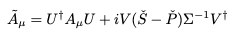

In [54]:
A_til_mu = ( 
    U_rot.conj().swapaxes(-1,-2) @ berry_conn_en[0] @ U_rot
    + 1j* Vh.conj().swapaxes(-1,-2) @ (S_check - P_check) @ np.linalg.inv(Sig_mat) @ Vh
)

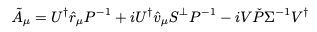

In [55]:
A_til_mu2 = (
    U_rot.conj().swapaxes(-1,-2) @ (rhat + 1j*vhat@ S_con) @ np.linalg.inv(P) 
        - 1j*Vh.conj().swapaxes(-1,-2) @ P_check @ np.linalg.inv(Sig_mat) @ Vh
)

Showing Eq. 25 and Eq. 27 are equivalent (no Hamiltonian Berry connection in $\check{P}$)

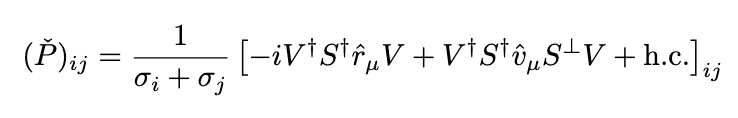

In [56]:
check_P2 = Vh @ S_occ.conj().swapaxes(-1,-2) @ (-1j*rhat + vhat @ S_con) @ Vh.conj().swapaxes(-1,-2)

for a in range(check_P2.shape[-2]):
    for b in range(check_P2.shape[-1]):
        check_P2[..., a, b] *= (1 / (Sig[..., a] + Sig[..., b]))

check_P2 = check_P2 + check_P2.conj().swapaxes(-1,-2)

In [57]:
check_P3 = W.conj().swapaxes(-1,-2) @ (-1j*rhat + vhat @ S_con) @ Vh.conj().swapaxes(-1,-2)

for a in range(check_P2.shape[-2]):
    for b in range(check_P2.shape[-1]):
        check_P3[..., a, b] *= (Sig[..., a] / (Sig[..., a] + Sig[..., b]))

check_P3 = check_P3 + check_P3.conj().swapaxes(-1,-2)

In [58]:
np.allclose(check_P2, check_P3)

True

In [59]:
A_til_mu3 = (
    U_rot.conj().swapaxes(-1,-2) @ (rhat + 1j * vhat @ S_con) @ np.linalg.inv(P) 
        - 1j*Vh.conj().swapaxes(-1,-2) @ check_P3 @ np.linalg.inv(Sig_mat) @ Vh
)

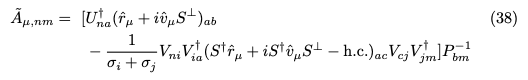

In [60]:
term =  S_occ.conj().swapaxes(-1,-2) @ (rhat + 1j*vhat@ S_con)
term = Vh @ term @ Vh.conj().swapaxes(-1,-2)

for a in range(term.shape[-2]):
    for b in range(term.shape[-1]):
        term[..., a, b] *= (1 / (Sig[..., a] + Sig[..., b]))

term = Vh.conj().swapaxes(-1,-2) @ term @ Vh
term  = term - term.conj().swapaxes(-1,-2)

A_til_mu4 = (
    U_p.conj().swapaxes(-1,-2) @ (rhat + 1j*vhat @ S_con)
    - term
) @ np.linalg.inv(P) 

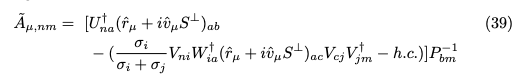

In [61]:
term = rhat + 1j * vhat @ S_con 
term = W.conj().swapaxes(-1,-2) @ term @ Vh.conj().swapaxes(-1,-2)

for a in range(term.shape[-2]):
    for b in range(term.shape[-1]):
        term[..., a, b] *= (Sig[..., a] / (Sig[..., a] + Sig[..., b]))

term = Vh.conj().swapaxes(-1,-2) @ term @ Vh
term  = term - term.conj().swapaxes(-1,-2)

A_til_mu5 = (
    U_p.conj().swapaxes(-1,-2) @ (rhat+ 1j*vhat @ S_con) 
    - term
) @ np.linalg.inv(P) 

In [62]:
print(np.allclose(check_P2, P_check))

True


In [63]:
print(np.allclose(A_til_mu, A_til_mu2))
print(np.allclose(A_til_mu, A_til_mu3))
print(np.allclose(A_til_mu, A_til_mu4))
print(np.allclose(A_til_mu, A_til_mu5))

True
True
True
True


In [64]:
A_til_mu[0].round(5)

array([[ 1.73274-0.j, -0.25377+0.j],
       [-0.25377-0.j,  5.34068+0.j]])

In [139]:
# A_til_mu6[0].round(5)

In [65]:
np.eye(2,2) - (S_occ.conj().swapaxes(-1,-2) @ S_occ)[0]

array([[0.02794354+0.j, 0.07319304+0.j],
       [0.07319304+0.j, 0.19171592+0.j]])

In [66]:
(S_con.conj().swapaxes(-1,-2) @ S_con)[0]

array([[0.02794354+0.j, 0.07319304+0.j],
       [0.07319304+0.j, 0.19171592+0.j]])

In [67]:
diff = A_til_mu3 - berry_conn_tilde[0]
print(np.amax(diff))

(4.568952095151957e-05+1.8452511393777544e-13j)


In [68]:
A_tilde_ad =  U_rot.conj().swapaxes(-1,-2) @ berry_conn_en[0] @ U_rot + 1j*UdagparU

diff = A_tilde_ad - berry_conn_tilde[0]
print(np.amax(diff))

(4.5689520933756e-05+1.1340534606335048e-13j)
